## Exercise 7.2

In [18]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [19]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green blue).

In [20]:
# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


We visualize some examples.

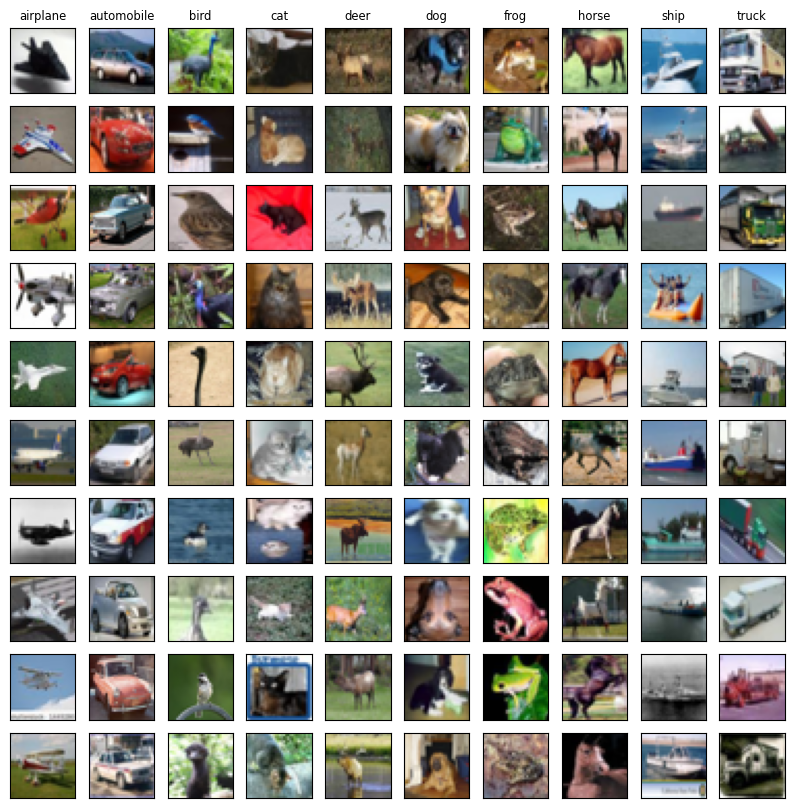

In [21]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train);

In the following block, we separate some of the test data for validation, we apply one-hot encoding for the labels, and we normalize the integer RGB values to the range (0,1).

In [22]:
# Hint: use 20% of the test data for validation
print(x_test.shape)
x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)

# Hint: normalize the data
x_train_norm = np.float32(x_train) / 255
x_valid_norm = np.float32(x_valid) / 255
x_test_norm = np.float32(x_test) / 255

(10000, 32, 32, 3)


### Classification with a dense net

In [23]:
# ----------------------------------------------------------
# Define model
# ----------------------------------------------------------
def dense_block(x, n=8):
    """ Create a block of n densely connected pairs of convolutions """
    xlist = [x]
    for i in range(n):
        x = layers.Conv2D(8, (3, 3), padding='same', activation='relu')(x)
        xlist.append(x)
        x = layers.concatenate(xlist[:], axis=-1)
    return x

x0 = layers.Input(shape=(32, 32, 3), name='input') # some tensor of shape say (n, nx, ny, 64)
x = dense_block(x0, n=5)
x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = layers.AveragePooling2D((2, 2), strides=(2, 2))(x)
x = dense_block(x, n=5)
x = layers.GlobalAveragePooling2D(name='final_globalpooling')(x)
x = layers.Dense(10, activation='softmax')(x)
model = keras.models.Model(inputs=[x0], outputs=[x], name='DenseNet')

print(model.summary())

Model: "DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 32, 32, 8) │        224 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_48      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 11)               │            │ conv2d_51[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 32, 32, 8) │        800 │ concatenate_48[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_49      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 19)               │            │ conv2d_51[0][0],  │
│                     │                   │            │ conv2d_52[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 32, 32, 8) │      1,376 │ concatenate_49[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_50      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 27)               │            │ conv2d_51[0][0],  │
│                     │                   │            │ conv2d_52[0][0],  │
│                     │                   │            │ conv2d_53[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 32, 32, 8) │      1,952 │ concatenate_50[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_51      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 35)               │            │ conv2d_51[0][0],  │
│                     │                   │            │ conv2d_52[0][0],  │
│                     │                   │            │ conv2d_53[0][0],  │
│                     │                   │            │ conv2d_54[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 32, 32, 8) │      2,528 │ concatenate_51[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_52      │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 43)               │            │ conv2d_51[0][0],  │
│                     │                   │            │ conv2d_52[0][0],  │
│                     │                   │            │ conv2d_53[0][0],  │
│                     │                   │            │ conv2d_54[0][0],  │
│                     │                   │            │ conv2d_55[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 32, 32,    │      2,816 │ concatenate_52[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 16, 16,    │          0 │ conv2d_56[0][0]   │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 16, 16, 8) │      4,616 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_53      │ (None, 16, 16,    │          0 │ average_pooling2… │
│ (Concatenate)       │ 72)               │            │ conv2d_57[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 16, 16, 8) │      5,192 │ concatenate_53[0

 Total params: 39,586 (154.63 KB)

 Trainable params: 39,586 (154.63 KB)

 Non-trainable params: 0 (0.00 B)

None


In [24]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

model.fit(
    x_train_norm, y_train_onehot,

    batch_size=32,
    epochs=25, # train at least for 20 epochs
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[CalculateMetrics(), 
               tf.keras.callbacks.CSVLogger("checkpoints/ex7.2/history_{}.csv".format(model.name))],
);

Epoch 1/25
1563/1563 - 47s - 30ms/step - accuracy: 0.3271 - loss: 1.7893 - val_accuracy: 0.4255 - val_loss: 1.5439 - train_loss: 1.5444 - train_acc: 0.4315
Epoch 2/25
1563/1563 - 45s - 29ms/step - accuracy: 0.4559 - loss: 1.4860 - val_accuracy: 0.5060 - val_loss: 1.3753 - train_loss: 1.3849 - train_acc: 0.4948
Epoch 3/25
1563/1563 - 45s - 29ms/step - accuracy: 0.5146 - loss: 1.3406 - val_accuracy: 0.5410 - val_loss: 1.2525 - train_loss: 1.2443 - train_acc: 0.5485
Epoch 4/25
1563/1563 - 45s - 29ms/step - accuracy: 0.5530 - loss: 1.2359 - val_accuracy: 0.5645 - val_loss: 1.2075 - train_loss: 1.1877 - train_acc: 0.5716
Epoch 5/25
1563/1563 - 45s - 29ms/step - accuracy: 0.5825 - loss: 1.1662 - val_accuracy: 0.5820 - val_loss: 1.1358 - train_loss: 1.1245 - train_acc: 0.5918
Epoch 6/25
1563/1563 - 45s - 29ms/step - accuracy: 0.6077 - loss: 1.0996 - val_accuracy: 0.6080 - val_loss: 1.0804 - train_loss: 1.0405 - train_acc: 0.6312
Epoch 7/25
1563/1563 - 45s - 29ms/step - accuracy: 0.6280 - loss

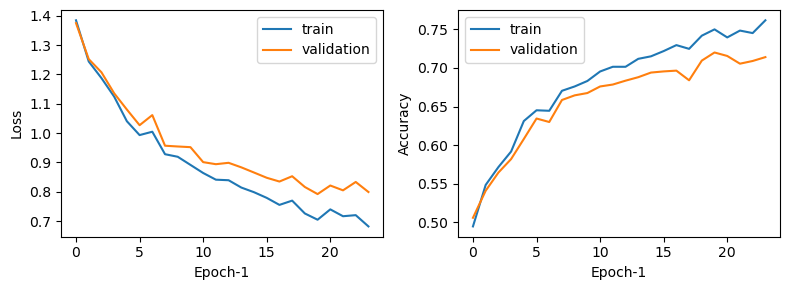

In [25]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("checkpoints/ex7.2/history_{}.csv".format(model.name), delimiter=",", names=True)
train_acc = history["train_acc"][1:]
val_acc = history["val_accuracy"][1:]
train_loss = history["train_loss"][1:]
val_loss = history["val_loss"][1:]

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(train_loss,label="train")
plt.plot(val_loss,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [26]:
# evaluate performance
print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |     Loss |   Accuracy |   Test error rate [%] |
|------------+----------+------------+-----------------------|
| Train      | 0.681614 |   0.76166  |               23.834  |
| Validation | 0.799002 |   0.714    |               28.6    |
| Test       | 0.787374 |   0.714125 |               28.5875 |


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


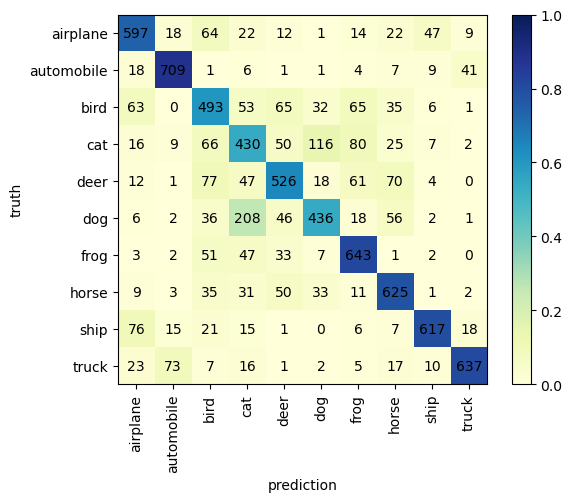

In [27]:
# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

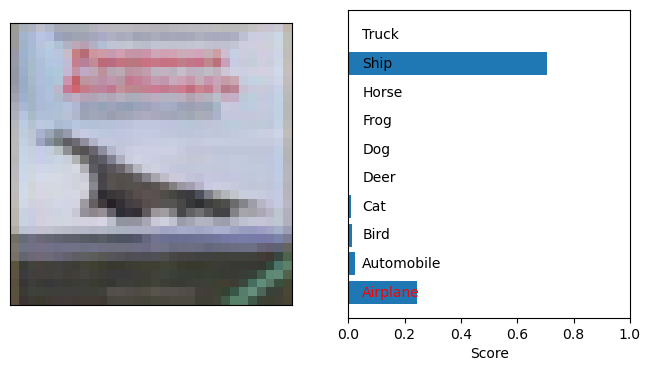

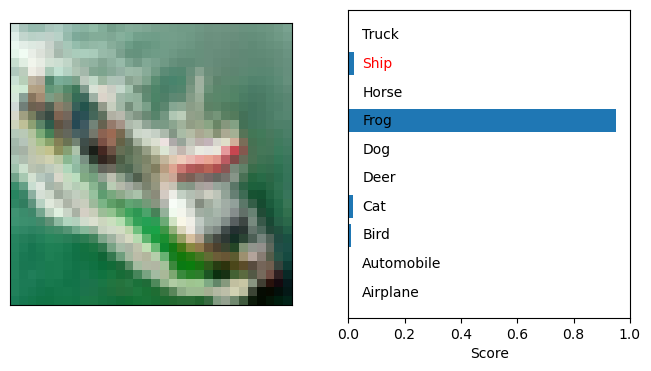

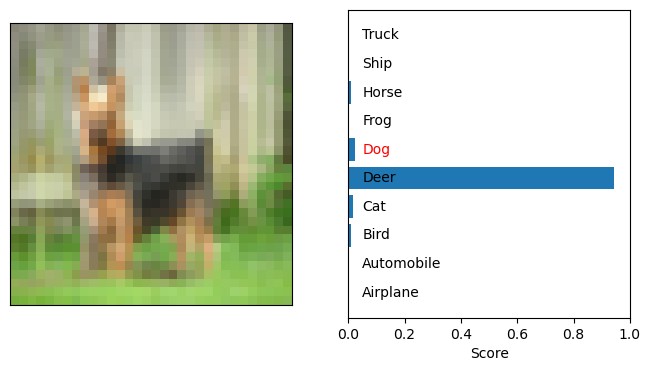

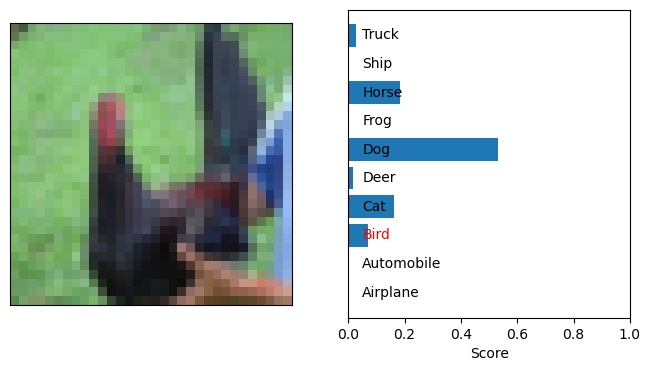

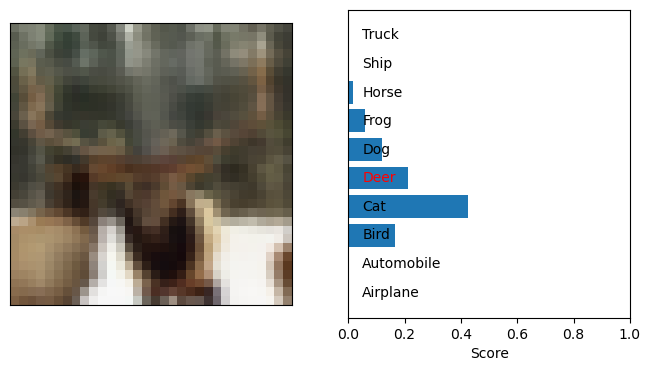

In [28]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 5 false classifications
for i in i0[0:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

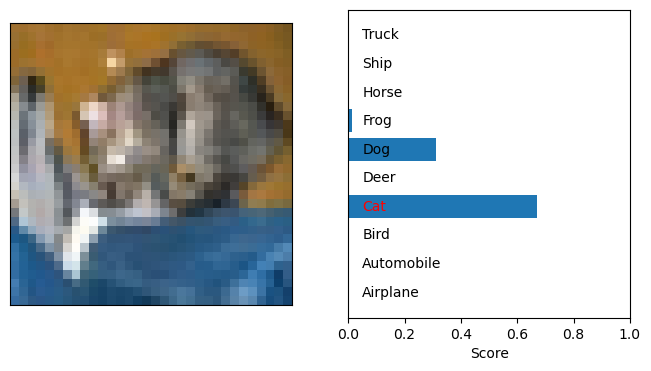

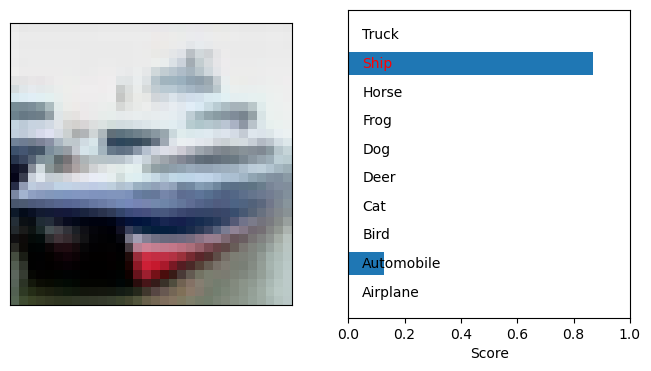

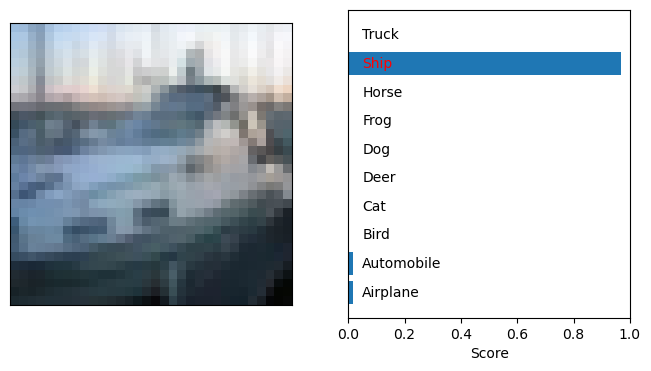

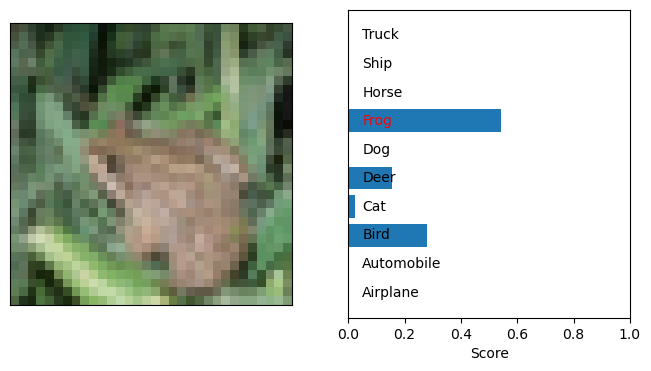

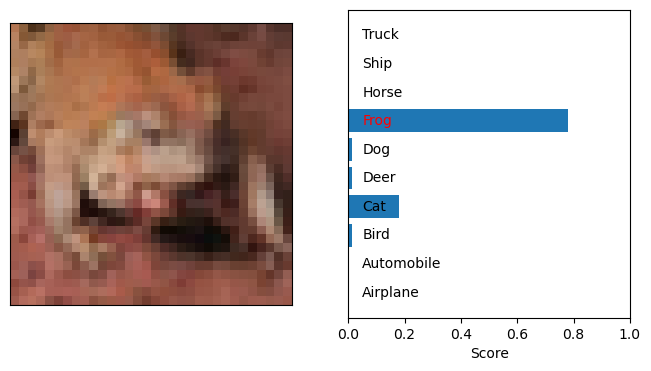

In [29]:
# plot first 5 correct classifications
for i in i1[0:5]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])